# Xplique: A Deep Learning Explainability Toolbox

Python 3.11.11
tensorflow==2.15.0
Xplique==1.4.0

Article initial : https://arxiv.org/pdf/2206.04394,
A Deep Learning Explainability Toolbox
Thomas Fel Lucas Hervier
David Vigouroux Antonin Poche
Justin Plakoo Remi Cadene Mathieu Chalvidal
Julien Colin Thibaut Boissin Louis Bethune Agustin Picard Claire Nicodeme
Laurent Gardes Gregory Flandin Thomas Serre

Dans ce notebook je vais présenter la bibliothèque Xplique. Xplique est donc une bibliothèque python qui met à disposition des outils d'expliquabilité pour les réseau de neuronnes. Xplique implémente une variété de méthode pour une variété de tâche. Les tâches supporter par Xplique sont la classification, l'object detection, la regression et semantic segmentation pour des données tabulaire, des images ou des textes. 

Il est important de différencier l'explicabilité local et global : 
- Fournit une vue d'ensemble du comportement du modèle sur l'ensemble des données, identifiant les caractéristiques les plus influentes et les tendances générales. Elle est utile pour détecter les biais systémiques et évaluer la robustesse du modèle.
- Se concentre sur des prédictions spécifiques, expliquant pourquoi un modèle a fait une certaine prédiction pour une instance particulière. Elle est essentielle pour le débogage et la personnalisation des explications, permettant de comprendre les erreurs individuelles.

Dans ce notebook je vais uniquement me concentrer sur les modèles de classification d'image et faire de l'explicabilité locale. **Le but de ce notebook est donc que pour chaque image avec un modèle entrainé on va essayer d'apporter des explication sur le choix de la classe du modèle**. Les documentations complètes de la bibliothèque se trouve sur le wiki de Xplique qui est super bien fait : https://deel-ai.github.io/xplique/latest/ 

Le but d'Xplique est d'unifier les différentes méthodes d'explicabilité sous une même librairy. On peut distinguer 3 catégories implémenté dans Xplique : 
- *Attributions Methods* : La bibliothèque implémente diverses méthodes d'attribution (e.g., Saliency, Grad-CAM, Integrated-Gradients) pour expliquer les décisions des modèles, avec des exemples et des références aux articles officiels.

- *Feature Visualization* : Ce module permet de visualiser comment les réseaux de neurones construisent leur compréhension des images en identifiant les entrées qui maximisent l'activation des neurones, canaux, couches ou leurs combinaisons.

- *Concepts* : Le module Concepts permet d'extraire des concepts humains d'un modèle et de tester leur pertinence par rapport à une classe, facilitant ainsi l'interprétation des décisions du modèle en termes compréhensibles.

<img src="images/3methodes.png">

# Attribution Method

## Introduction

Les méthodes d'attribution sont des techniques d'explicabilité particulièrement utilisées pour les réseaux de Deep Learning. Ces méthodes attribuent une importance à des pixels ou à des groupes de pixels dans une image, en fonction de leur influence sur une prédiction donnée. Elles permettent ainsi de comprendre quelles parties de l'image ont le plus contribué à la décision du modèle.

L'API Xplique propose une implémentation de 14 de ces méthodes d'attribution. Elle offre une syntaxe simple et intuitive pour mettre en œuvre ces techniques, facilitant ainsi leur utilisation par les chercheurs et les praticiens du domaine. Xplique se distingue par sa capacité à fournir des explications claires et interprétables, ce qui est crucial pour le développement de modèles de Deep Learning transparents et fiables.

Malgrès l'unification par l'API de la syntaxe on peut distinguer 2 méthodes : 

- **Perturbation-based approaches** : Les méthodes basées sur la perturbation consistent à modifier une entrée à l'aide de diverses techniques, puis à analyser les sorties résultantes pour déterminer une représentation d'attribution. Ces méthodes ne nécessitent pas une connaissance explicite de l'architecture du modèle, tant que la transmission des entrées et sorties est possible. C'est pourquoi elles sont souvent qualifiées de méthodes « boîtes noires ».

    - Par exemple, la méthode LIME segmente une image en super-pixels (groupes de pixels). À partir de l'image à expliquer, elle génère de nombreuses variantes en masquant certains super-pixels. En analysant les prédictions obtenues à partir de ces variantes, LIME identifie les pixels ayant le plus d'influence sur la décision du modèle.
<img src="images/lime_explication.jpg">

- **Gradient-based approaches** : Ces approches sont également appelées "méthodes boîtes blanches", car elles nécessitent un accès complet à l'architecture du modèle, notamment pour calculer les gradients. L'idée centrale des approches basées sur le gradient est d'utiliser la rétropropagation, non pas pour mettre à jour les poids du modèle (qui est déjà entraîné), mais pour révéler les entrées les plus contributives, potentiellement dans une couche spécifique.

    - Exemple avec la méthode GradCAM : L'objectif ici n'est pas d'expliquer en détail le fonctionnement de la méthode, mais de montrer comment l'explicabilité peut être obtenue grâce aux gradients. On note ```f``` le classifieur, ```x``` une image,donc ```f(x)``` est la classe de l'image choisie par le classifieur. Soit une couche k dans un CNN, on va donc appliquer différent filtre à notre image.  A est un ensemble de filtres appliqués à une couche. Dans une couche du réseau convolutif (lorsque l'on travaille toujours en 2D), on peut, grâce à la rétropropagation, calculer :

    $$ \omega_k = \sum_i \sum_j \frac{\partial f(x)}{\partial A_{i,j}^k} $$ 

    Ce terme représente la sensibilité d'une région de pixels à la classe f(x). Ainsi, si un groupe de pixels est important pour le choix de la classe de x, le modifier entraînera une modification de la classe f(x), ce qui se traduira par un gradient élevé (petite perturbation -> changement de classe -> pixel important). Ainsi, en calculant les gradients par rétropropagation, on peut connaître l'importance de chaque groupe de pixels.

    <img src="images/GradCAM.png">

    


On va maintenant explorer un peu l'API à travers 2 modèles et 2 dataset : 
- Le premier modèle est ```MobileNetV2```, ce modèle est déjà entrainé. C'est un classifier qui classifie des animaux. Il y a 1000 classes d'animaux. En entrée on prend une image RGB de taille 224x224 et on sort un vecteur de probabilité (donné par softmax) d'appartenance de l'image au classe. 

- Le deuxième modèle est ```Aircraft_model``` un modèle qu'on a entrainé en cours à detecter si un ou des avions étaient présent sur l'image ou non. Le modèle prend en entré des images RGB de taille 64x64 et retourne de la même manière que ```MobileNetV2```, renvoie un vecteur de probabilité. $[0,1]$ est le vecteur "à coup sur c'est un avion et $[1,0]$ est le vecteur "à coup sur ce n'est pas un avion".

## Les modèles et data
Dans cette section on charge les modèles et les datasets. Les 2 modèles ont déjà été pré-entrainés. 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
from math import ceil
import cv2
import tensorflow.keras.applications as app
import pandas as pd

%matplotlib inline
%config InlineBackend.figure_format='retina'

2025-02-09 22:41:01.490429: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-09 22:41:01.920412: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-09 22:41:01.920516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-09 22:41:02.005855: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-09 22:41:02.132670: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-09 22:41:02.134553: I tensorflow/core/platform/cpu_feature_guard.cc:1

### MobileNetV2 et la classification d'annimaux.

In [ ]:
# Dé-commentez pour télécharger les images dans ./data/

# downloading image from unsplash...
# !wget -nv 'https://unsplash.com/photos/X2PwqTUpXH8/download?force=true&w=640' -O './data/fox1.jpg'
# !wget -nv 'https://unsplash.com/photos/tIfrzHxhPYQ/download?force=true&w=640' -O './data/fox2.jpg'
# !wget -nv 'https://unsplash.com/photos/LVnJlyfa7Zk/download?force=true&w=640' -O './data/sea_turtle.jpg'
# !wget -nv 'https://unsplash.com/photos/sSEEbAzB6fU/download?force=true&w=640' -O './data/lynx.jpg'
# !wget -nv 'https://unsplash.com/photos/41dAczoRYJY/download?force=true&w=640' -O './data/cat.jpg'
# !wget -nv 'https://unsplash.com/photos/axqTLZ12Jss/download?force=true&w=640' -O './data/otter.jpg'

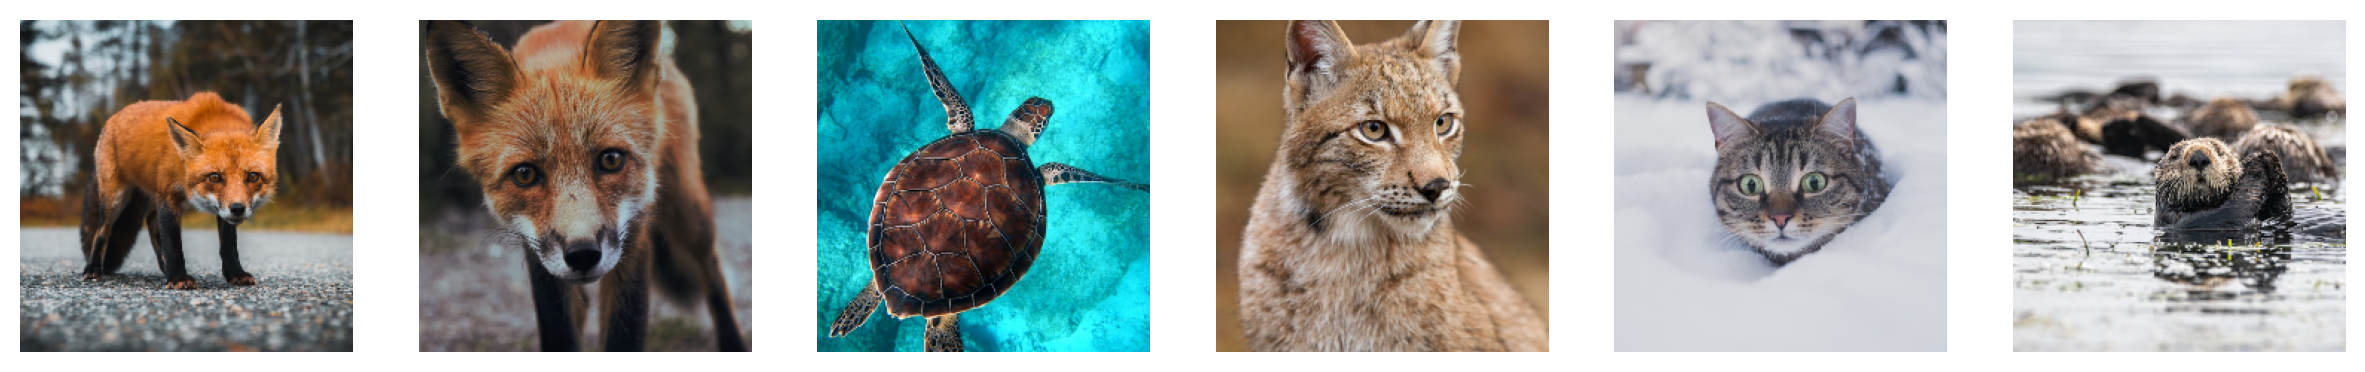

In [4]:
img_list_mobilenet = [
    ('./data/fox1.jpg', 277),
    ('./data/fox2.jpg', 277),
    ('./data/sea_turtle.jpg', 33),
    ('./data/lynx.jpg', 287),
    ('./data/cat.jpg', 281),
    ('./data/otter.jpg', 360)
]

def central_crop_and_resize_for_mobile_net(img, size=224):
  """
  Given a numpy array, extracts the largest possible square and resizes it to
  the requested size (224x224 pour MobileNetV2)
  Notre modèle qu'on utilise est MobileNetV2 qui prend des images de taille 224x224, on doit donc redimensioner
  nos images
  """
  h, w, _ = img.shape

  min_side = min(h, w)
  max_side_center = max(h, w) // 2.0

  min_cut = int(max_side_center-min_side//2)
  max_cut = int(max_side_center+min_side//2)

  img = img[:, min_cut:max_cut] if w > h else img[min_cut:max_cut]
  img = tf.image.resize(img, (size, size))

  return img

X_mobilenet = []
Y_mobilenet = []

for img_name, label in img_list_mobilenet:
    img = cv2.imread(img_name)[..., ::-1] # when cv2 load an image, the channels are inversed
    img = central_crop_and_resize_for_mobile_net(img)
    label = tf.keras.utils.to_categorical(label, 1000)
    X_mobilenet.append(img)
    Y_mobilenet.append(label)

X_mobilenet = np.array(X_mobilenet, dtype=np.float32)
Y_mobilenet = np.array(Y_mobilenet, dtype=np.int8)

plt.rcParams["figure.figsize"] = [15, 6]
for img_id, img in enumerate(X_mobilenet):
  plt.subplot(1, len(X_mobilenet), img_id+1)
  plt.imshow(img/255.0)
  plt.axis('off')

In [5]:
# load the model and preprocess the inputs (adapt the input range)
mobilenet_model, mobilenet_preprocessing = app.MobileNetV2(), app.mobilenet_v2.preprocess_input
X_mobilenet_preprocessed = tf.convert_to_tensor(mobilenet_preprocessing(np.array(X_mobilenet, copy=True)))

In [6]:
output = mobilenet_model.predict(X_mobilenet_preprocessed[:1])
print(np.argmax(output), ", 277 est bien la classe des renard")

1/1 [==============================] - 1s 1s/step
277 , 277 est bien la classe des renard


### Classification d'avion

In [2]:
TOY_DATASET_URL = "https://storage.googleapis.com/fchouteau-isae-deep-learning/toy_aircraft_dataset_2023.npz"

ds = np.lib.npyio.DataSource(destpath="/tmp/")
f = ds.open(TOY_DATASET_URL, "rb")
toy_dataset = np.load(f)

trainval_images_aircraft : np.ndarray = toy_dataset["train_images"]
trainval_labels_aircraft : np.ndarray = toy_dataset["train_labels"]
trainval_labels_aircraft = tf.keras.utils.to_categorical(trainval_labels_aircraft, 2)
test_images_aircraft : np.ndarray = toy_dataset["test_images"]
test_labels_aircraft : np.ndarray = toy_dataset["test_labels"]
test_labels_aircraft = tf.keras.utils.to_categorical(test_labels_aircraft, 2)

In [3]:
# On charge notre modèle déjà entrainé
aircraft_model = tf.keras.models.load_model("./model/aircraft_model.h5")
aircraft_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 62, 62, 16)        448       
                                                                 
 conv2d_6 (Conv2D)           (None, 60, 60, 16)        2320      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 28, 28, 32)        4640      
                                                                 
 conv2d_8 (Conv2D)           (None, 26, 26, 32)        9248      
                                                                 
 conv2d_9 (Conv2D)           (None, 24, 24, 32)        9248      
                                                      

In [4]:

def preprocessing_for_aircraft(image) :
    # Les moyennes et écart type ont été calculé à partir du dataset d'entrainement. 
    mean = np.array([0.33012513, 0.34202802, 0.32268534])
    std = np.array([0.16872728, 0.16531856, 0.16314243])
    # Normalize pixel values to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    # Standardize using the mean and std of the dataset
    image = (image - mean) / std

    return image

In [5]:
test_images_norm_aircraft = preprocessing_for_aircraft(np.array(test_images_aircraft, copy=True))
test_loss, test_acc = aircraft_model.evaluate(test_images_norm_aircraft, test_labels_aircraft)
print(f"Test accuracy: {test_acc}")

28/28 [==============================] - 1s 22ms/step - loss: 0.9610 - accuracy: 0.8605
Test accuracy: 0.8604910969734192


Dans notre modèle de détection d'avions, nous avons une précision de 86 %. Grâce à cela, nous allons pouvoir utiliser nos outils d'explicabilité pour voir où notre modèle se trompe.

## Implémentation de l'API

In [6]:
from xplique.attributions import (Saliency, GradientInput, IntegratedGradients, SmoothGrad, VarGrad,
                                  SquareGrad, GradCAM, Occlusion, Rise, GuidedBackprop,
                                  GradCAMPP, Lime, KernelShap, SobolAttributionMethod)
import xplique
from xplique.plots import plot_attributions

On va implementer notre API. Il nous faut donc des modèles déja entrainé sur lequel on va appliquer nos méthodes d'explicabilité. 
Déclaration dans Xplique. 
```
explainer = Method(model, batch_size, operator)
explanation = explainer(inputs, targets)
```
L'API de Xplique est plutôt simple pour l'utiliser. On définit un ```explainer``` qui est une instance de ```Method```. 
- ```Method``` : est l'une des méthode d'explicabilité comme ```GradCAM``` ou ```Lime```.
- ```model``` : est le modèle qu'on va utiliser pour nos prédiction. Nous travaillerons sur nos 2 modèles différents. Le premier est MobileNetV2 implémenter directement dans tensorflow. Le deuxième est aircraft_model, c'est un modèle qu'on a entrainé dans le cours sur les CNN pour reconaître ou non des avions avec des images satélites.
- ```batch_size``` : Pour les méthodes *Gradient-based*, on peut calculer les gradients par batch. C'est donc la taille du batch qu'on précise ici.
- ```operator``` : C'est la tache du model (Classification, Object Detection, Regression et Segmantic Segmentation). On choisi de travailler que avec des Classifier, on ne précisera donc rien dans ```operator```.

Ensuite on appel le ```explainer```. On veut donc expliquer quel pixel contribue à associer des classes dans target à des images dans input. A noter que dans target on est pas obligé de donner la classe la plus probable donné par notre modèle.  

Ensuite pour chaque méthode on aura des paramètres suplémentaires spécifique à la méthode. Par exemple pour ```Lime``` on aura ```nb_sample```, le nombre d'image perturber à généré. 


In [7]:
# on choisi notre modèle qu'on veut expliquer et le data set qu'on explique, décomenenter pour utiliser

model_a_utilise = "Aircraft"

if model_a_utilise == "MobileNetV2" :
    # Model pour la detection d'animaux
    model = mobilenet_model
    images = X_mobilenet
    inputs = X_mobilenet_preprocessed
    targets = Y_mobilenet
elif model_a_utilise == "Aircraft" :
    # Model pour les aircrafts
    model = aircraft_model
    images = np.array(
        [test_images_aircraft[i] for i in range(len(test_labels_aircraft)) if (test_labels_aircraft[i] == [0., 1.]).all()]
        )[:6]
    inputs = preprocessing_for_aircraft(images)
    targets = tf.keras.utils.to_categorical(np.ones(inputs.shape[0]), 2)
else :
    print("prenez un bon modèle")


Premier test avec ```GradientInput``` pour nous familiariser avec l'API. Vous pouvez choisir n'importe qu'elle autre 
Perturbation-based approaches (peut être un peu long à calculer): 
- KernelShap
- Lime
- Occlusion
- Rise 
- Sobol Attribution
- Hsic Attribution 

Gradient-based approaches : 
- DeconvNet
- GradCAM
- GradCAM++
- GradientInput
- GuidedBackpropagation
- IntegratedGradients
- Saliency
- SmoothGrad
- SquareGrad
- VarGrad 


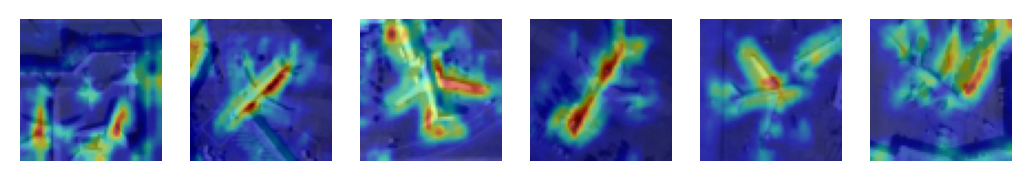

In [8]:
# to explain the logits is to explain the class,
# to explain the softmax is to explain why this class rather than another
# it is therefore recommended to explain the logit
model.layers[-1].activation = tf.keras.activations.linear

# Ici on choisi la méthode
explainer = GradCAMPP(model)
explanations = explainer(inputs, targets)

# plot the attribution on top of the image
for i in range(len(images)):
  plt.subplot(1, len(images), i+1)
  plt.imshow(images[i]/255.0)
  plt.imshow(explanations[i], cmap="jet", alpha=0.5)
  plt.axis('off')

Nous pouvons maintenant utiliser autant de méthodes que nous le souhaitons et comparer leurs résultats.

Method: GradientInput


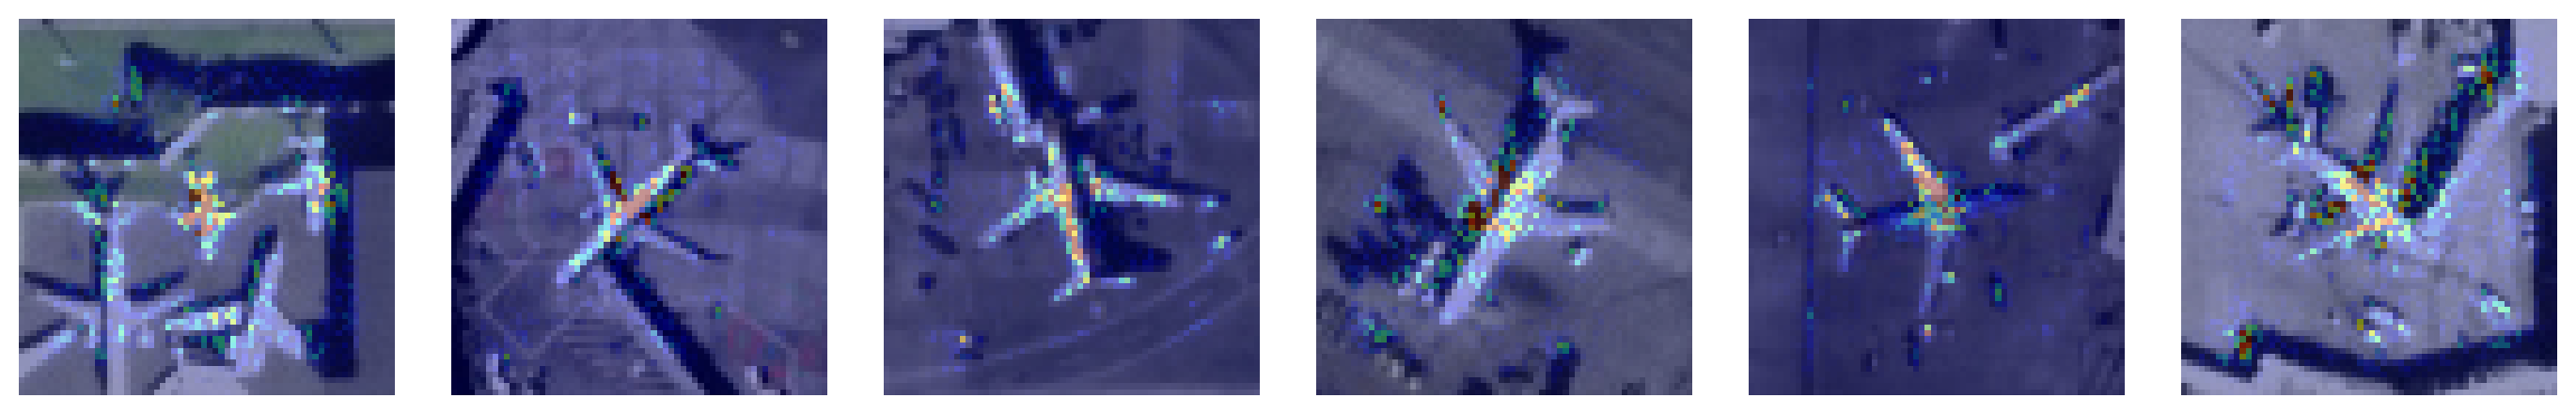



Method: GuidedBackprop


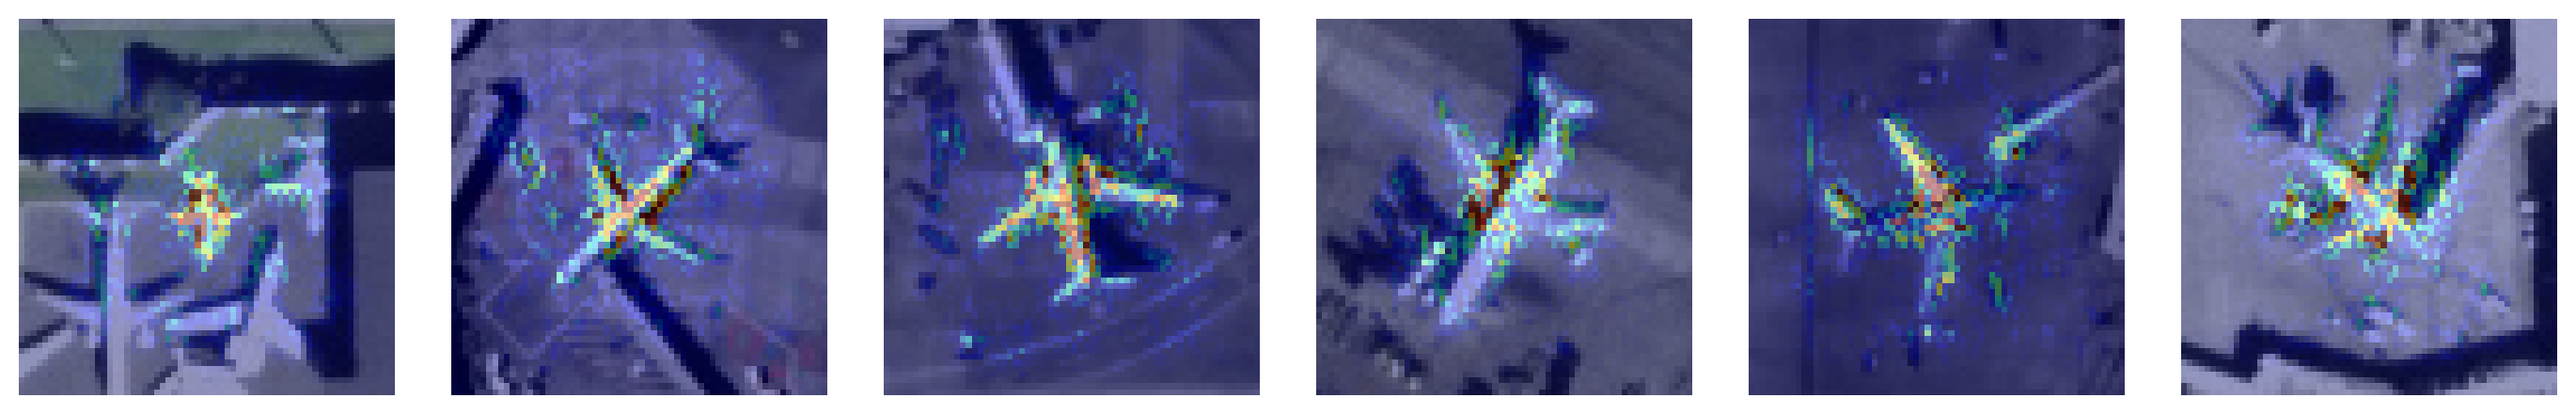



Method: IntegratedGradients


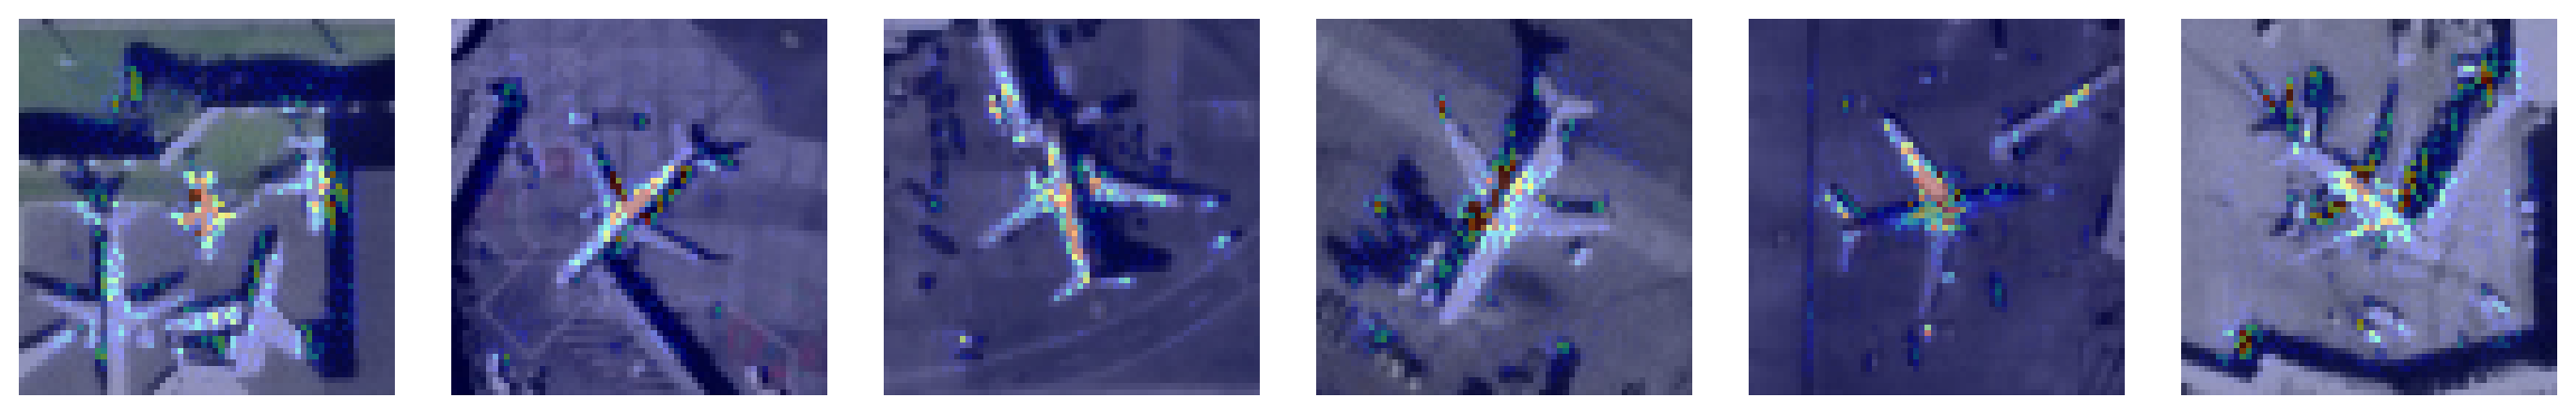



Method: GradCAM


/home/bolympio/miniconda3/envs/cryptoenv/lib/python3.11/site-packages/xplique/plots/image.py:30: RuntimeWarning: invalid value encountered in divide
  image /= image.max()


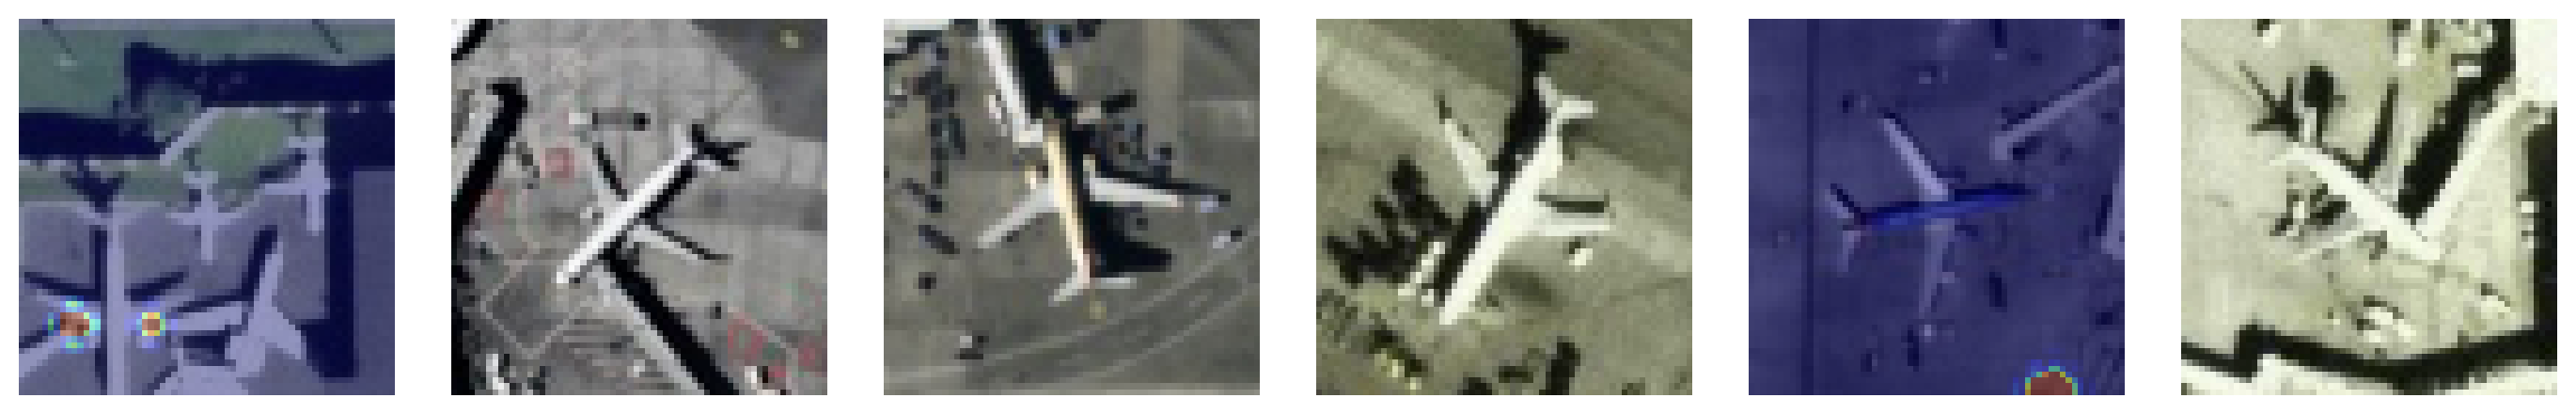



Method: Lime


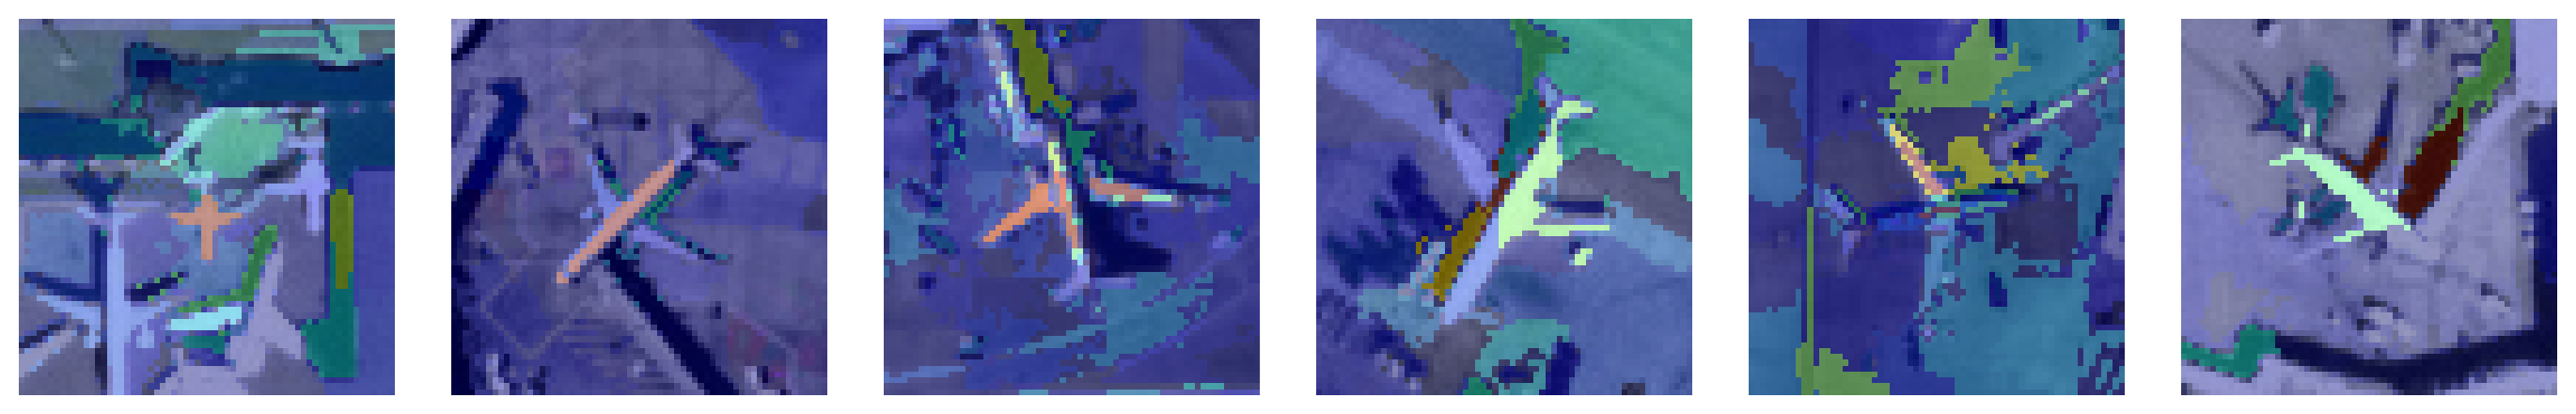

In [9]:
# La dernière couche d'activation est normalement un softmax qui permet d'avoir une distribution de probabilité
# pour chaque classe. On retire la fonction d'activation pour la remplacer par du linéaire. 
# On fait cela car les méthodes Gradient-Base regarde pourquoi tel ou tel neuronne est maximisé (donc avant softmax) et 
# non pourquoi telle ou tel neuronne à la plus grande probabilité d'être choisi (après softmax)
model.layers[-1].activation = tf.keras.activations.linear
batch_size = 64

explainers = [
            #  Saliency(model),
             GradientInput(model),
             GuidedBackprop(model),
             IntegratedGradients(model, steps=80, batch_size=batch_size),
            #  SmoothGrad(mobilenet_model, nb_samples=80, batch_size=batch_size),
            #  SquareGrad(model, nb_samples=80, batch_size=batch_size),
            #  VarGrad(model, nb_samples=80, batch_size=batch_size),
             GradCAM(model),
            #  Occlusion(mobilenet_model, patch_size=10, patch_stride=5, batch_size=batch_size),
            #  Rise(model, nb_samples=4000, batch_size=batch_size),
            #  SobolAttributionMethod(model, batch_size=batch_size)
             Lime(model, nb_samples = 300),
            #  KernelShap(model, nb_samples = 1000)
]

for explainer in explainers:

  explanations = explainer(inputs, targets)

  print(f"Method: {explainer.__class__.__name__}")
  plot_attributions(explanations, images, img_size=2., cmap='jet', alpha=0.4,
                    cols=len(images), absolute_value=True, clip_percentile=0.5)
  plt.show()
  print("\n")

### Metrics

On vient donc d'exhiber les explication de 5 méthodes : 
- GradientInput
- GuidedBackprop
- IntegratedGradients
- GradCAM
- Lime

Visuellement on remarque des différences dans l'interprétation des différentes méthodes. Elle n'ont pas mise en valeur les mêmes portions des images. Notament ```GradCAM``` qui semble ne pas s'appuyer sur la présence d'avion pour détecter... des avions. Cependant cela ne veut pas dire que ```GradCAM``` est mauvais. Il se peut que le réseau de neuronne s'appuie sur l'environement de l'aéroport plutôt que les avions eux mêmes.

On a donc une nécéssité d'avoir une métrique indépendante du point de vue humain pour classifier les méthodes. On introduit donc 2 métrique qui se base **seulement** sur les variations des probabilité que l'image appartiennent à une classe ou une autre. 

- Une première classe de métrique est celle qui va modifier les pixels les plus importants donnés par la carte de chaleur d'une méthode et observer les probabilité d'apartenir à la classe. Ces méthodes sont ```Deletion```, ```Insertion``` et ```MuFidelity``` implémetés par Xplique.

- La seconde ```Stability```, va observer si pour des images similaires avec la même classe prédites on obtient à peu près les mêmes explication.


Explication de l'API :
Notre principale fonction est ```BaseAttributionMetric(model, inputs, targets, batch_size)``` :
- ```model``` est le réseau de neuronne
- ```inputs``` sont les images pre process
- ```targets``` sont les label qu'on veut expliquer 
- ```batch_size``` est un hyperparamètre.

/home/bolympio/miniconda3/envs/cryptoenv/lib/python3.11/site-packages/xplique/attributions/lime.py:129: UserWarning: You set a number of perturbed samples per input >= 500 and batch_size is set to NoneThis mean that you will ask your model to handle more than 500 perturbed samples per input at once.This can lead to OOM issue. To avoid it you can set the batch_size argument.
  warnings.warn(


Method: GradientInput


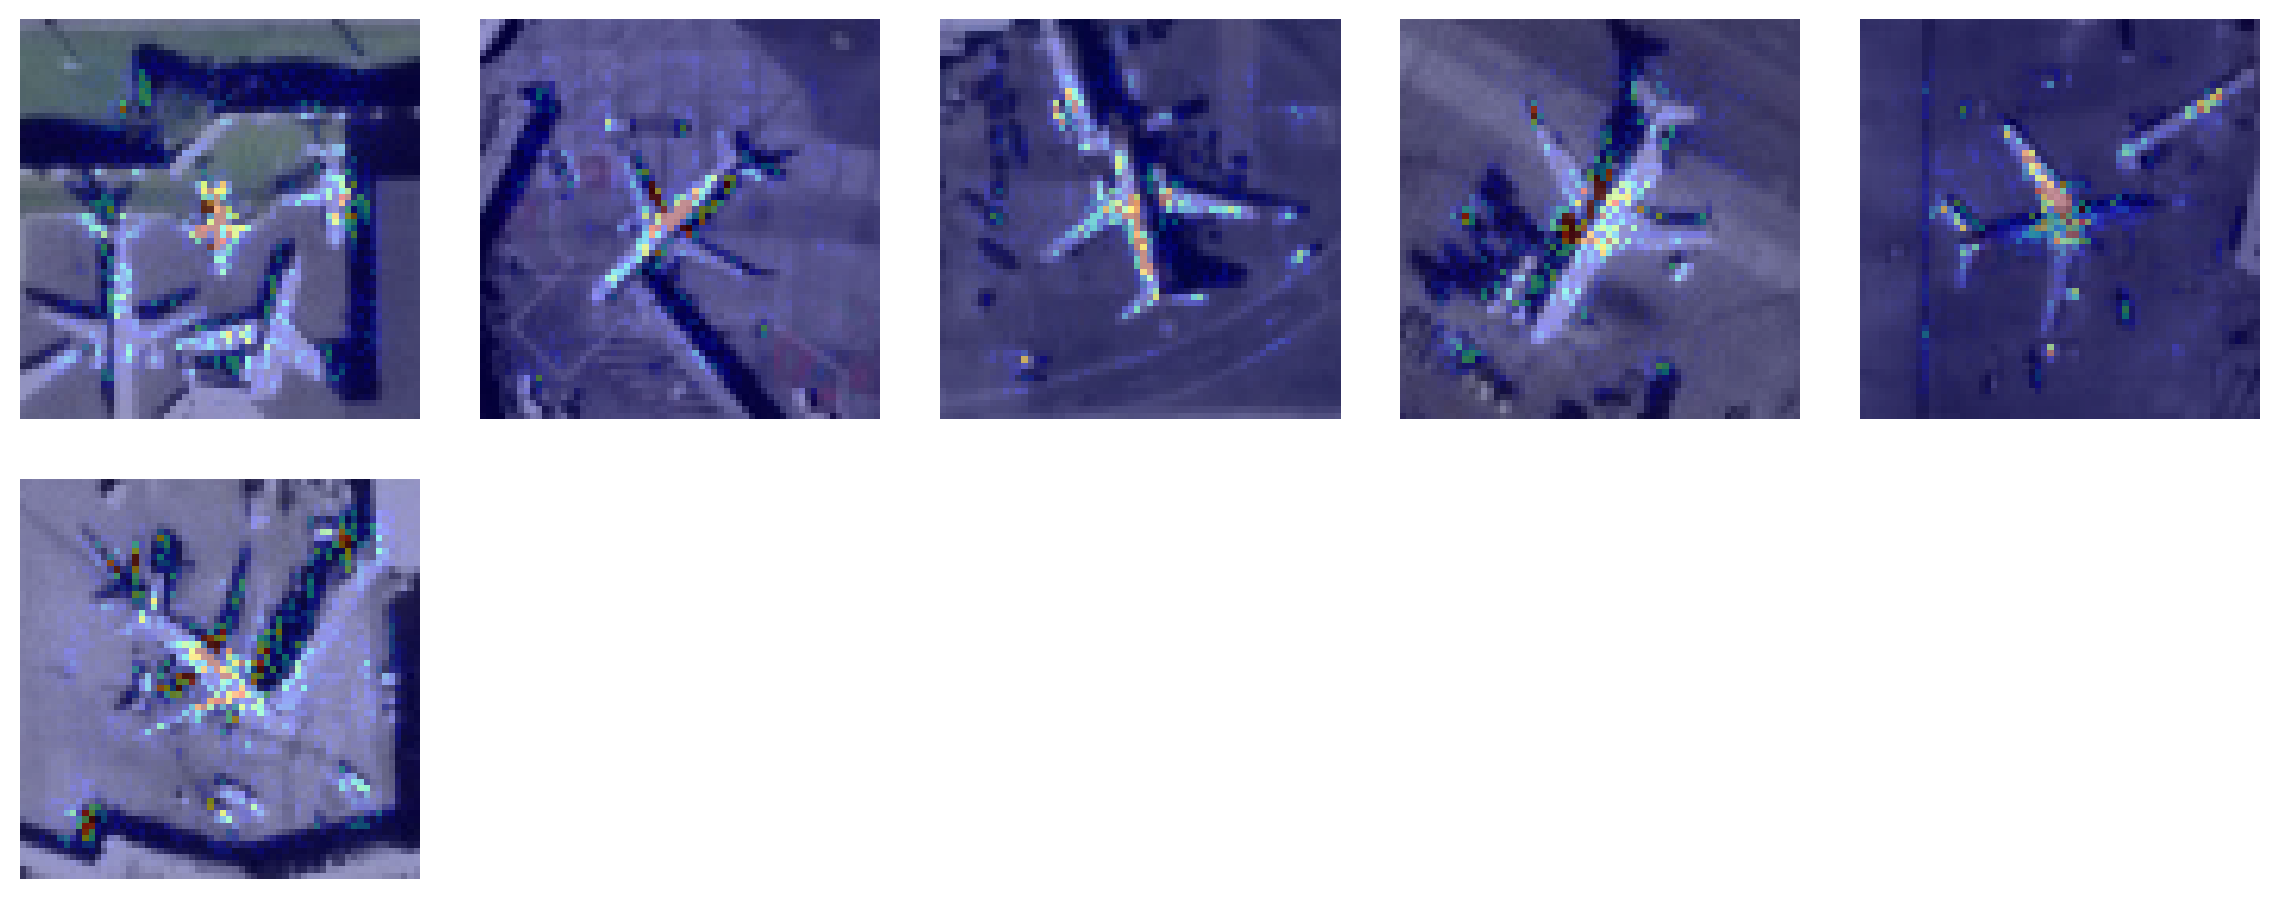



Method: GuidedBackprop


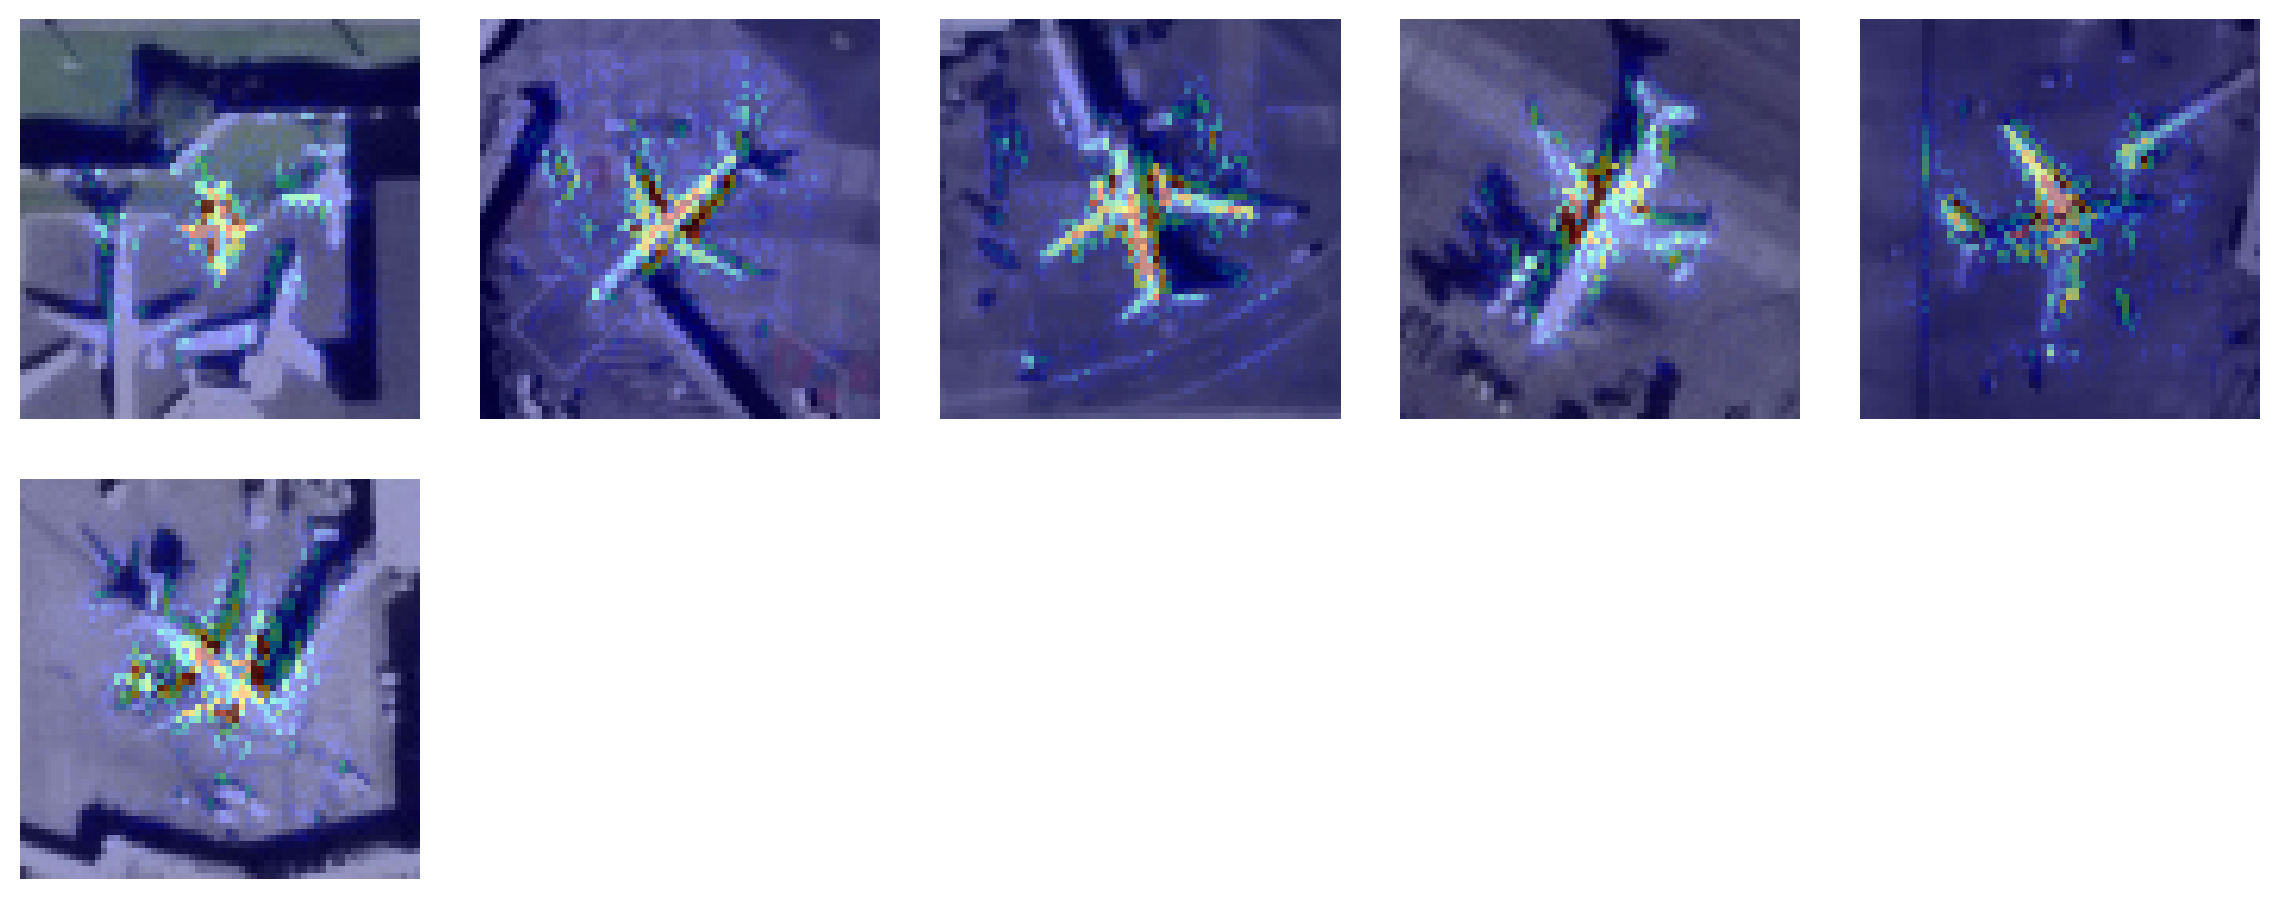



Method: IntegratedGradients


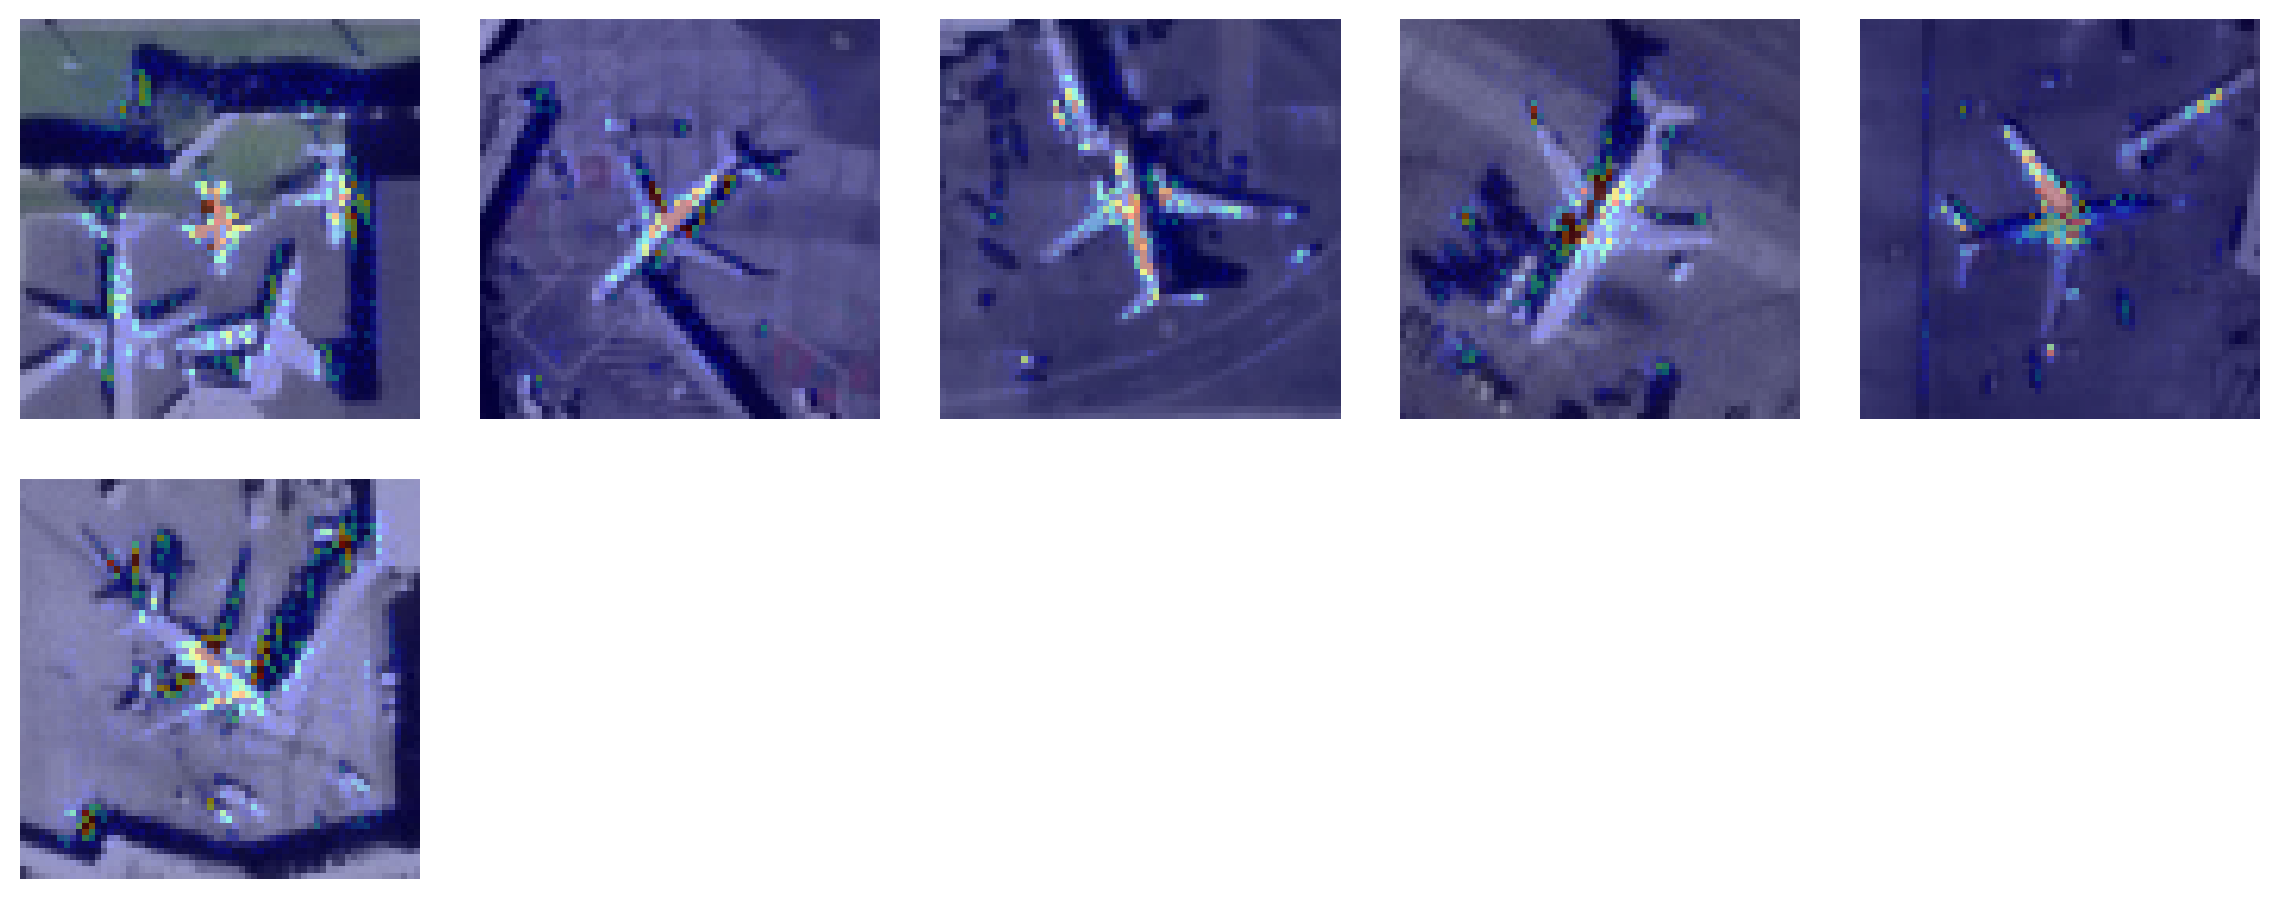



Method: GradCAM


/home/bolympio/miniconda3/envs/cryptoenv/lib/python3.11/site-packages/xplique/plots/image.py:30: RuntimeWarning: invalid value encountered in divide
  image /= image.max()


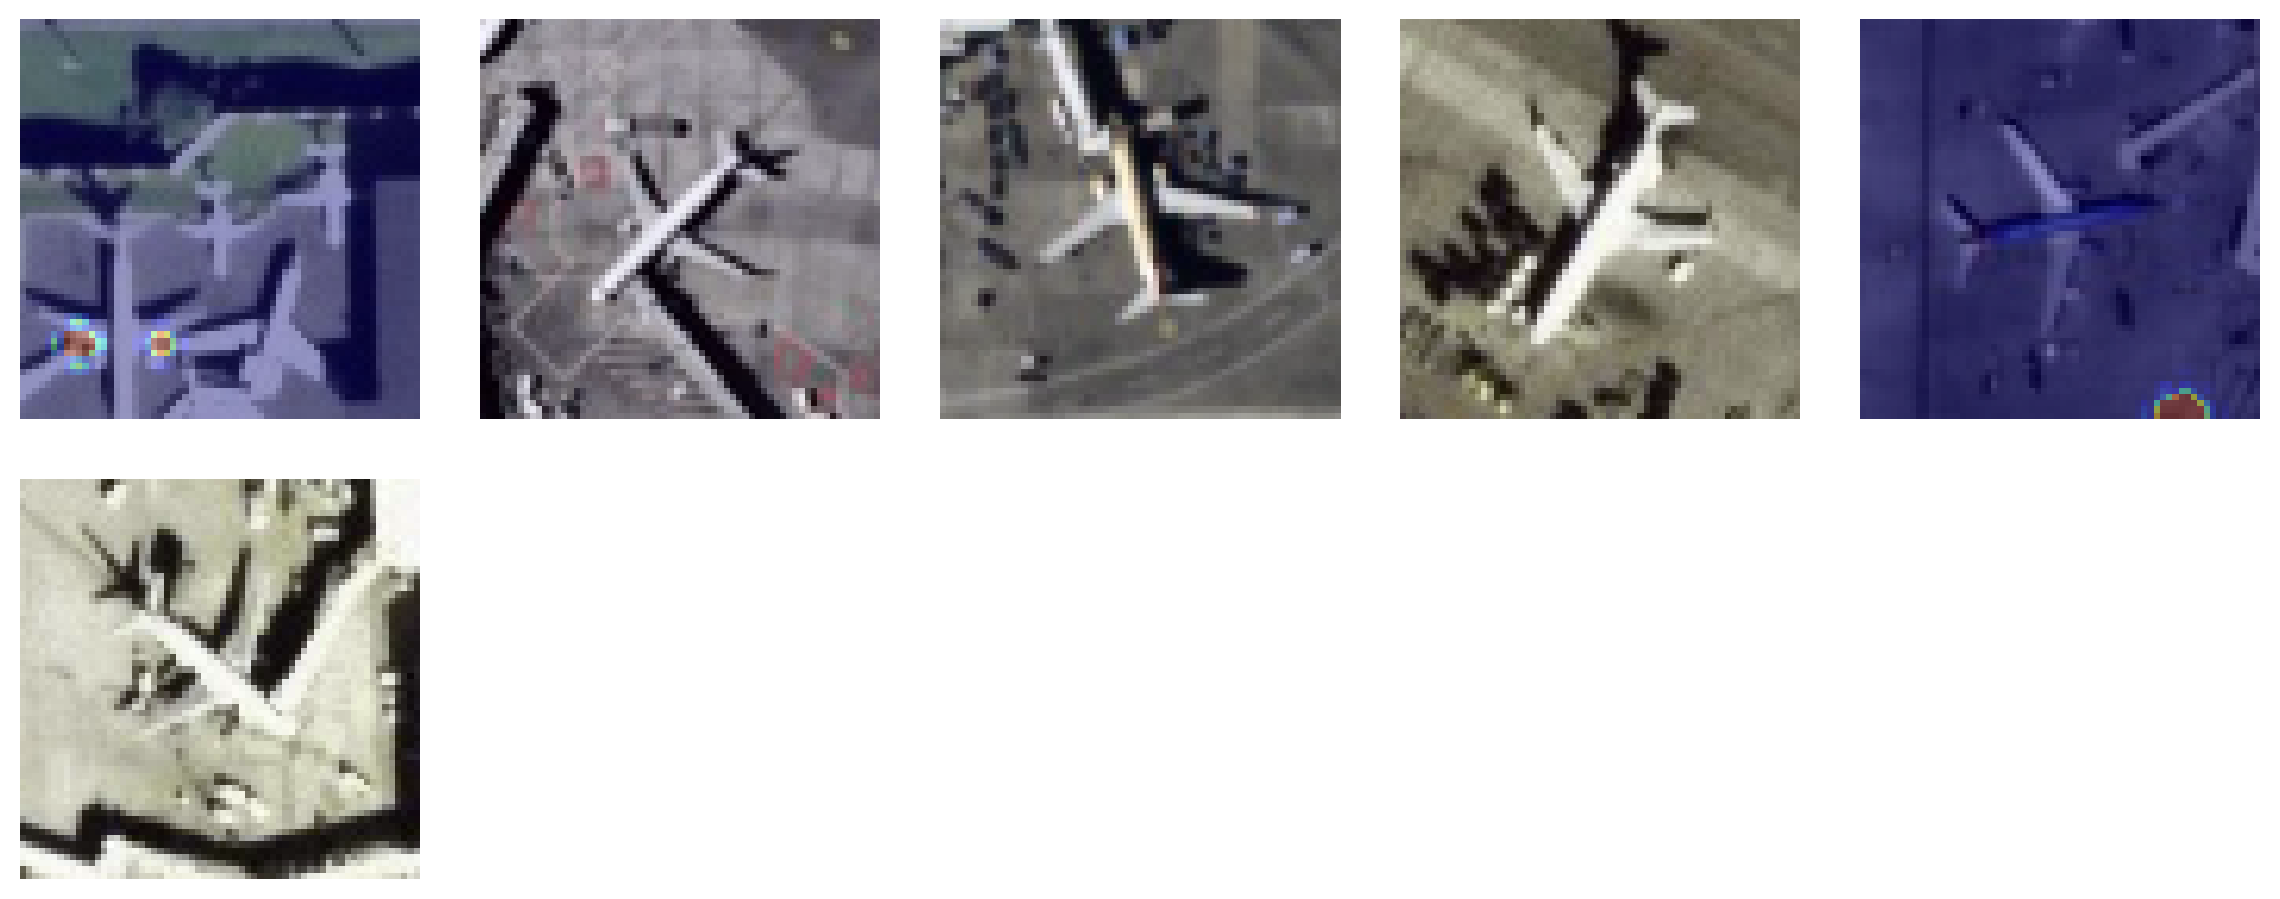



Method: Lime


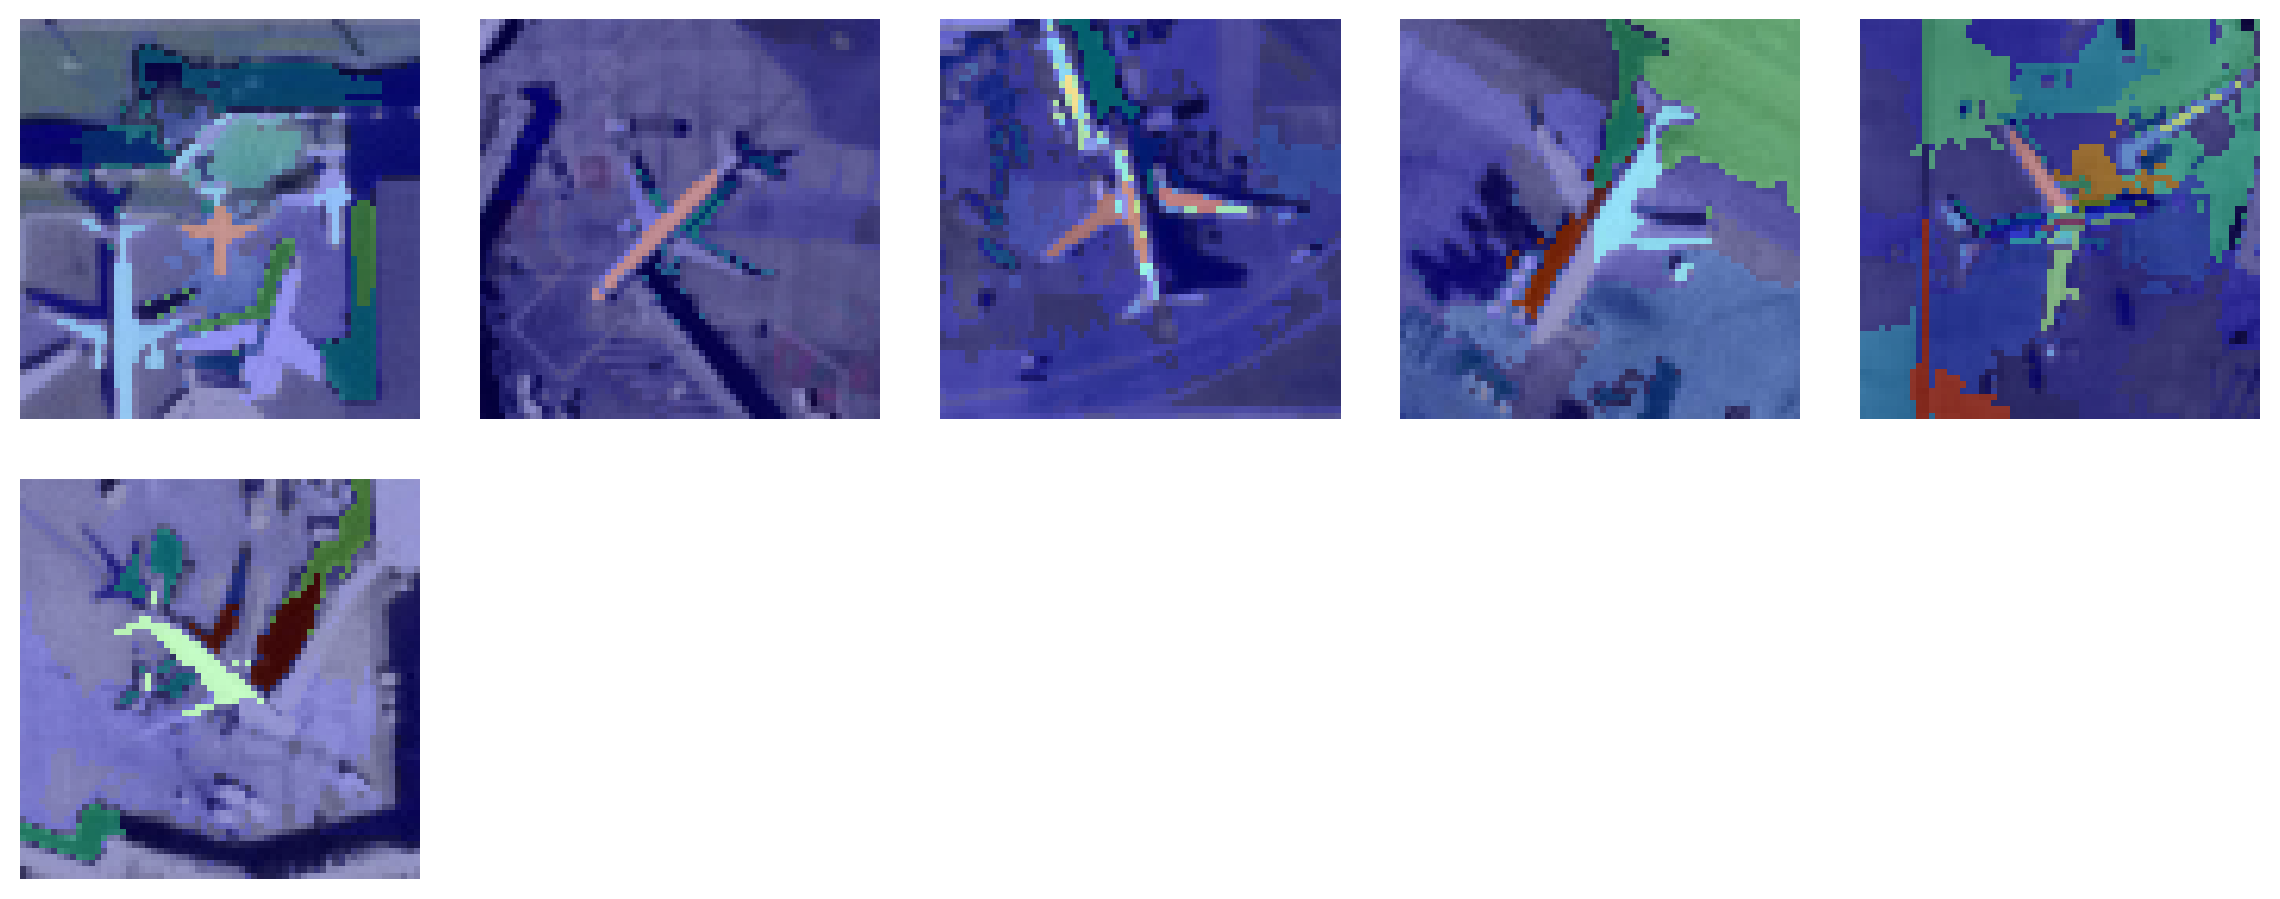

In [10]:
from xplique.attributions import (Saliency, GradientInput, IntegratedGradients, SmoothGrad, VarGrad,
                                  SquareGrad, GradCAM, Occlusion, Rise, GuidedBackprop,
                                  GradCAMPP, Lime, KernelShap, SobolAttributionMethod)

# to explain the logits is to explain the class,
# to explain the softmax is to explain why this class rather than another
# it is therefore recommended to explain the logit
model.layers[-1].activation = tf.keras.activations.linear
batch_size = 64

explainers = [
            #  Saliency(model),
             GradientInput(model),
             GuidedBackprop(model),
             IntegratedGradients(model, steps=50, batch_size=batch_size),
            #  SmoothGrad(model, nb_samples=50, batch_size=batch_size),
            #  SquareGrad(model, nb_samples=50, batch_size=batch_size),
            #  VarGrad(model, nb_samples=50, batch_size=batch_size),
             GradCAM(model),
            #  GradCAMPP(model),
            #  Occlusion(model, patch_size=10, patch_stride=10, batch_size=batch_size),
            #  SobolAttributionMethod(model, batch_size=batch_size),
             # Rise(model, nb_samples=4000, batch_size=batch_size),
             Lime(model, nb_samples = 1000),
             # KernelShap(model, nb_samples = 1000)
]

explanations_to_test = {}

for explainer in explainers:

  explainer_name = explainer.__class__.__name__
  explanations = explainer(inputs, targets)

  if len(explanations.shape) > 10:
    explanations = np.mean(explanations, -1)

  # store the explanations to use the metrics
  explanations_to_test[explainer_name] = explanations

  print(f"Method: {explainer_name}")
  plot_attributions(explanations, inputs, cmap='jet', alpha=0.4,
                    cols=5, clip_percentile=0.5, absolute_value=True)
  plt.show()
  print("\n")

In [11]:
from xplique.metrics import Deletion

metric = Deletion(model, inputs, targets, batch_size)
deletion_scores = []

i = 0
for explanation_name, explanations in explanations_to_test.items():
  deletion_score = metric(explanations)
  deletion_scores.append((explanation_name, deletion_score))

pd.DataFrame(deletion_scores, columns=["Method name", "Deletion score (lower is better)"])

,Method name,Deletion score (lower is better)
0,GradientInput,-25.859818
1,GuidedBackprop,-8.623983
2,IntegratedGradients,-26.755802
3,GradCAM,0.850063
4,Lime,-18.536217


In [12]:
from xplique.metrics import Insertion

metric = Insertion(model, inputs, targets, batch_size)
insertion_scores = []

i = 0
for explanation_name, explanations in explanations_to_test.items():
  insertion_score = metric(explanations)
  insertion_scores.append((explanation_name, insertion_score))

pd.DataFrame(insertion_scores, columns=["Method name", "Insertion score (higher is better)"])

,Method name,Insertion score (higher is better)
0,GradientInput,22.452312
1,GuidedBackprop,5.956243
2,IntegratedGradients,22.930630
3,GradCAM,3.214059
4,Lime,16.282875


In [13]:
from xplique.metrics import MuFidelity

metric = MuFidelity(model, inputs, targets, batch_size, nb_samples=25)
fidelity_scores = []

i = 0
for explanation_name, explanations in explanations_to_test.items():
  fidelity_score = metric(explanations)
  fidelity_scores.append((explanation_name, fidelity_score))

pd.DataFrame(fidelity_scores, columns=["Method name", "Fidelity score (higher is better)"])

/home/bolympio/miniconda3/envs/cryptoenv/lib/python3.11/site-packages/xplique/metrics/fidelity.py:158: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_score = spearmanr(pred, attr)[0]


,Method name,Fidelity score (higher is better)
0,GradientInput,0.838077
1,GuidedBackprop,0.127179
2,IntegratedGradients,0.837051
3,GradCAM,0.025250
4,Lime,0.337949


In [14]:
from xplique.metrics import AverageStability

metric = AverageStability(model, inputs[:20], targets[:20], batch_size, nb_samples=32)
stability_scores = []

i = 0
for explainer in explainers:
  explainer_name = explainer.__class__.__name__
  stability_score = metric(explainer)
  stability_scores.append((explainer_name, stability_score))

pd.DataFrame(stability_scores, columns=["Method name", "Stability score (lower is better)"])

,Method name,Stability score (lower is better)
0,GradientInput,0.430534
1,GuidedBackprop,0.164530
2,IntegratedGradients,0.233738
3,GradCAM,0.001521
4,Lime,49.025375


Dans ce travail, nous avons exploré diverses techniques d'attribution pour l'explicabilité des modèles de Deep Learning, en nous appuyant sur la bibliothèque Xplique. Nous avons identifié deux principales catégories de méthodes : celles basées sur la perturbation et celles basées sur les gradients. Chaque méthode offre des perspectives uniques et produit des résultats différents, soulignant l'importance de pouvoir les évaluer de manière rigoureuse. À cette fin, l'utilisation de métriques appropriées est essentielle pour comparer et valider ces approches. Il est crucial de reconnaître que, tout comme le domaine du Deep Learning lui-même, l'explicabilité reste un champ très empirique, nécessitant des expérimentations et des ajustements continus pour progresser.